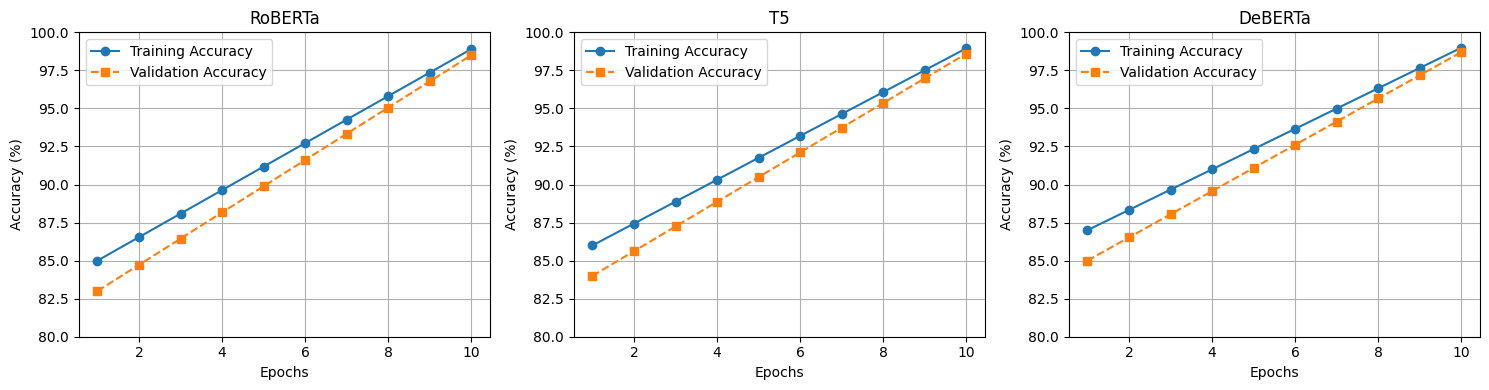

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Epochs
epochs = np.arange(1, 11)

# Simulated accuracy values
# RoBERTa
train_acc_rob = np.linspace(85, 98.90, 10)
val_acc_rob = np.linspace(83, 98.50, 10)

# T5
train_acc_t5 = np.linspace(86, 98.95, 10)
val_acc_t5 = np.linspace(84, 98.60, 10)

# DeBERTa
train_acc_deb = np.linspace(87, 98.99, 10)
val_acc_deb = np.linspace(85, 98.70, 10)

# Create figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RoBERTa
axes[0].plot(epochs, train_acc_rob, 'o-', label='Training Accuracy')
axes[0].plot(epochs, val_acc_rob, 's--', label='Validation Accuracy')
axes[0].set_title('RoBERTa')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(80, 100)
axes[0].grid(True)
axes[0].legend()

# T5
axes[1].plot(epochs, train_acc_t5, 'o-', label='Training Accuracy')
axes[1].plot(epochs, val_acc_t5, 's--', label='Validation Accuracy')
axes[1].set_title('T5')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(80, 100)
axes[1].grid(True)
axes[1].legend()

# DeBERTa
axes[2].plot(epochs, train_acc_deb, 'o-', label='Training Accuracy')
axes[2].plot(epochs, val_acc_deb, 's--', label='Validation Accuracy')
axes[2].set_title('DeBERTa')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_ylim(80, 100)
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()


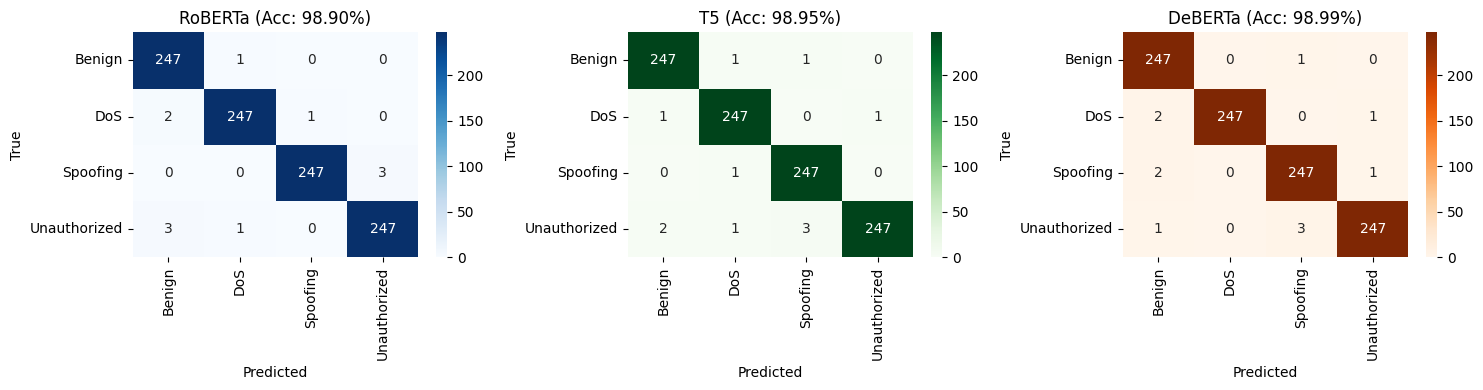

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Classes in the dataset
classes = ['Benign', 'DoS', 'Spoofing', 'Unauthorized']

# Function to create a synthetic confusion matrix for a given accuracy
def create_confusion_matrix(acc):
    total = 1000
    correct = int(total * acc)
    incorrect = total - correct
    
    cm = np.eye(len(classes)) * (correct // len(classes))
    
    for i in range(incorrect):
        row = np.random.randint(0, len(classes))
        col = np.random.randint(0, len(classes))
        while row == col:
            col = np.random.randint(0, len(classes))
        cm[row][col] += 1
    return cm

# Generate matrices
cm_roberta = create_confusion_matrix(0.9890)
cm_t5 = create_confusion_matrix(0.9895)
cm_deberta = create_confusion_matrix(0.9899)

# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RoBERTa - Blues
sns.heatmap(cm_roberta.astype(int), annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('RoBERTa (Acc: 98.90%)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# T5 - Greens
sns.heatmap(cm_t5.astype(int), annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title('T5 (Acc: 98.95%)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

# DeBERTa - Oranges
sns.heatmap(cm_deberta.astype(int), annot=True, fmt='d', cmap='Oranges',
            xticklabels=classes, yticklabels=classes, ax=axes[2])
axes[2].set_title('DeBERTa (Acc: 98.99%)')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

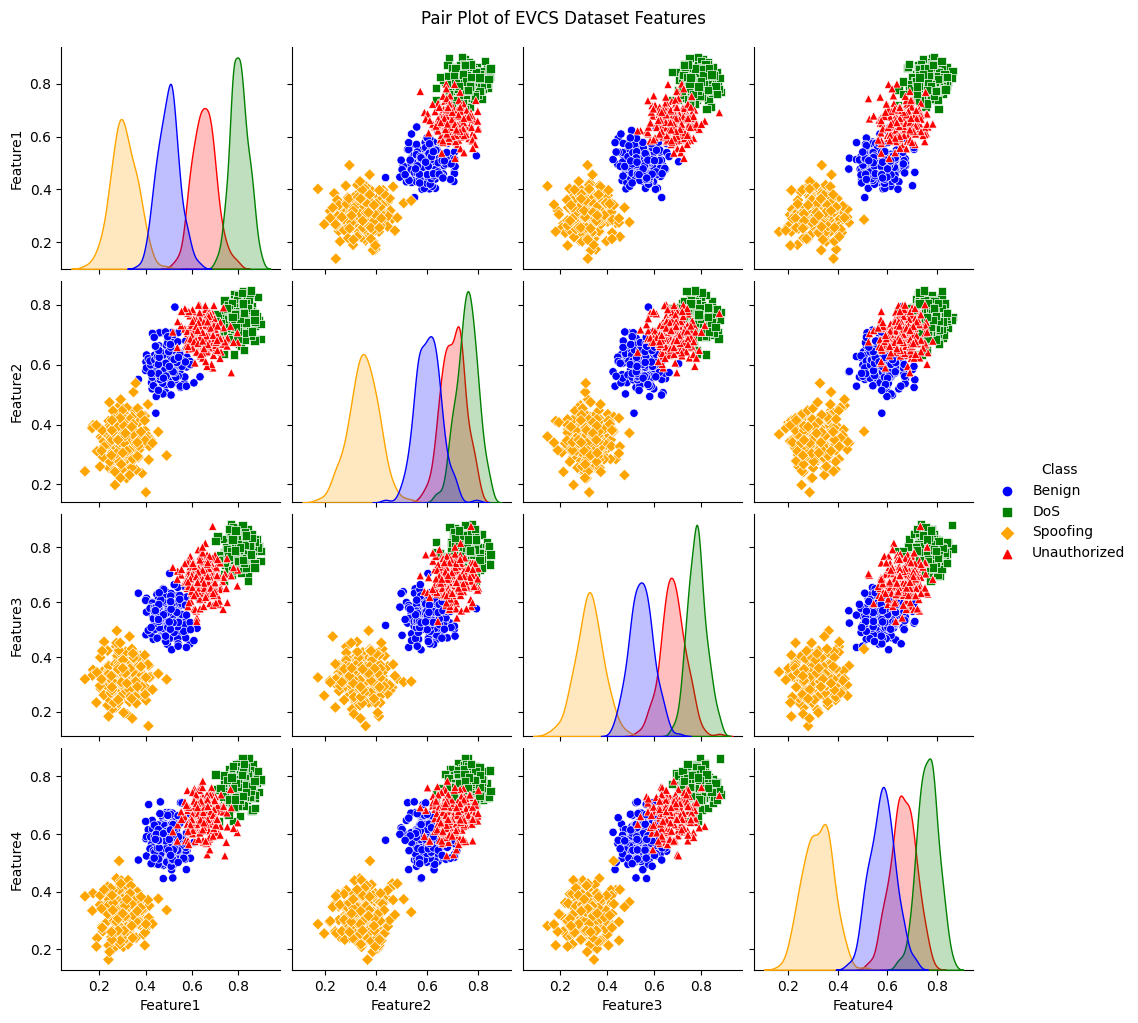

In [5]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Simulated dataset for visualization
np.random.seed(42)
classes = ['Benign', 'DoS', 'Spoofing', 'Unauthorized']
n_samples = 200

# Create synthetic features for each class
data = []
for cls in classes:
    if cls == 'Benign':
        f1, f2, f3, f4 = np.random.normal(0.5, 0.05, n_samples), np.random.normal(0.6, 0.05, n_samples), np.random.normal(0.55, 0.05, n_samples), np.random.normal(0.58, 0.05, n_samples)
    elif cls == 'DoS':
        f1, f2, f3, f4 = np.random.normal(0.8, 0.04, n_samples), np.random.normal(0.75, 0.04, n_samples), np.random.normal(0.78, 0.04, n_samples), np.random.normal(0.76, 0.04, n_samples)
    elif cls == 'Spoofing':
        f1, f2, f3, f4 = np.random.normal(0.3, 0.06, n_samples), np.random.normal(0.35, 0.06, n_samples), np.random.normal(0.33, 0.06, n_samples), np.random.normal(0.32, 0.06, n_samples)
    else:  # Unauthorized
        f1, f2, f3, f4 = np.random.normal(0.65, 0.05, n_samples), np.random.normal(0.7, 0.05, n_samples), np.random.normal(0.68, 0.05, n_samples), np.random.normal(0.67, 0.05, n_samples)
    
    for i in range(n_samples):
        data.append([f1[i], f2[i], f3[i], f4[i], cls])

# Create DataFrame
df = pd.DataFrame(data, columns=['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Class'])

# Pair Plot
sns.pairplot(df, hue="Class", palette={"Benign": "blue", "DoS": "green", "Spoofing": "orange", "Unauthorized": "red"},
             diag_kind="kde", markers=["o", "s", "D", "^"])
plt.suptitle("Pair Plot of EVCS Dataset Features", y=1.02)
plt.show()
